# Bài 16: Xử lý Dữ liệu Raster và Ảnh Vệ tinh với Rasterio
Rasterio là thư viện Python chuyên nghiệp cho việc đọc, ghi và xử lý dữ liệu raster địa lý - từ ảnh vệ tinh đến mô hình độ cao số.

## 16.1. Mục tiêu học tập

Sau khi hoàn thành bài học này, bạn sẽ có thể:

- Đọc và hiểu dữ liệu raster với metadata và properties chi tiết
- Xử lý coordinate systems và transformations cho dữ liệu raster
- Trực quan hóa dữ liệu raster với matplotlib và các hàm từ rasterio
- Thực hiện tính toán trên dữ liệu raster và band operations phức tạp
- Optimize memory usage với windowed reading cho big datasets
- Viết và reproject rasters với các hàm nâng cao
- Tích hợp Rasterio với NumPy và các thư viện khác.


In [ ]:
# Import thư viện cốt lõi
import rasterio
from rasterio.windows import Window
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, transform_bounds, Resampling
import geopandas as gpd
from rasterio.transform import from_bounds, from_origin, Affine
import numpy as np
from pyproj import CRS
import matplotlib.pyplot as plt

�️ Rasterio version: 1.5.0


## 16.2. Tạo và lưu dữ liệu
Hiểu cách tạo dữ liệu và lưu dữ liệu dưới dạng GeoTIFF cơ bản. Trong phần này, chúng ta sẽ tìm hiểu

- **Tạo raster datasets** từ đầu
- **Thiết lập meta** cho dữ liệu raster
- **Lưu dữ liệu** ra file

### 16.2.1. Tạo dữ liệu cho vùng nghiên cứu

Dữ liệu raster là một dạng dữ liệu địa lý được tổ chức dưới dạng một lưới các ô vuông (pixels), trong đó mỗi ô pixel chứa một giá trị đại diện cho thông tin về mặt đất tại vị trí đó. Ví dụ, một ảnh vệ tinh có thể được lưu dưới dạng raster, với mỗi pixel chứa giá trị phản ánh độ sáng hoặc màu sắc của khu vực tương ứng trên mặt đất. Dữ liệu raster thường được sử dụng để biểu diễn các hiện tượng liên tục như nhiệt độ, độ cao, hoặc NDVI (chỉ số thực vật), và có thể được phân tích để trích xuất thông tin về môi trường, nông nghiệp, hoặc đô thị.

Trong ví dụ dưới, ta có thể tạo ra dữ liệu raster ngẫu nhiên và gắn chúng vào khu vực nghiên cứu xác định sẵn thông qua bounding box. Dữ liệu raster có các thông tin cơ bản như độ phân giải (số hàng và số cột), ngoài ra còn thông tin về kênh màu (band). 

In [ ]:
# Đầu tiên thiết lập bounding box cho khu vực nghiên cứu. Ví dụ đây là khu vực thành phố vĩnh yên, vĩnh phúc
bounds = (105.5491712751346, 21.265278731790968, 105.64026044494432, 21.34612710736172)
# Tạo lưới tọa độ
height, width = 300, 338  # Resolution hợp lý (~30m)
x = np.linspace(bounds[0], bounds[2], width) # Tọa độ X
y = np.linspace(bounds[1], bounds[3], height) # Tọa độ Y
X, Y = np.meshgrid(x, y) # Tạo lưới 2D
# Tạo dữ liệu raster mẫu (giá trị ngẫu nhiên từ 0 đến 255, trong thực tế thì sẽ là dữ liệu đo đạc)
data = np.random.randint(0, 255, (height, width)).astype('uint8')

### 16.2.2. Thiết lập meta data cho dữ liệu

Để tạo một file raster từ dữ liệu numpy array, bạn cần thiết lập các thông số meta cho file raster, bao gồm `driver`, `dtype`, `nodata`, `width`, `height`, `count`, `crs`, `transform` và `compress`. Sau đó, bạn có thể sử dụng thư viện Rasterio để mở một file mới và ghi dữ liệu vào đó. Trong ví dụ dưới, chúng ta tạo một file GeoTIFF chứa dữ liệu ngẫu nhiên với hệ tọa độ WGS84 và nén dữ liệu bằng thuật toán LZW để giảm dung lượng file.

In [ ]:
# Thiết lập transform
transform = from_bounds(*bounds, width=width, height=height)
# Meta data 
meta = {
    'driver': 'GTiff', # Lưu dữ liệu ra dạndạng GeoTIFF
    'dtype': 'uint8', # Loại dữ liệu lưu là dạng unsigned int 8 bit
    'nodata': None, # Không có giá trị nodata
    'width': width, # Chiều rộng raster
    'height': height, # Chiều cao raster
    'count': 1, # Số band
    'crs': CRS.from_epsg(4326), # Hệ tọa độ WGS84
    'transform': transform, # Biến đổi affine,
    'compress': 'lzw' # Nén dữ liệu để giảm dung lượng file
}

### 16.2.3. Lưu dữ liệu 

Sau khi đã định nghĩa các thông số meta cho file raster, bạn có thể sử dụng thư viện Rasterio để mở một file mới và ghi dữ liệu vào đó.

In [ ]:
# Ghi dữ liệu raster vào file GeoTIFF
outfile = r'G:\My Drive\python\geocourse\data\raster\random_raster.tif'
with rasterio.open(outfile, 'w', **meta) as dst:
    dst.write(data, 1)  

## 16.3. Đọc file raster và Khám phá Metadata

Hiểu cách mở file raster và kiểm tra các thuộc tính cơ bản là nền tảng để làm việc với dữ liệu raster.

### 16.3.1. Đọc dữ liệu file raster

Đọc raster bằng thư viện Rasterio cho phép bạn truy cập vào dữ liệu raster dưới dạng numpy array, cũng như các thông tin meta liên quan đến raster như hệ tọa độ, biến đổi affine, và các thuộc tính khác. Điều này giúp bạn dễ dàng thực hiện các thao tác xử lý và phân tích dữ liệu raster trong Python.

In [ ]:
# Đọc dữ liệu ảnh Landsat RBG + NIR (30m resolution)
with rasterio.open(r'G:\My Drive\python\geocourse\data\raster\landsat_rgbn.tif') as src:
    img = src.read() # Dữ liệu ở định dạng numpy array. Ta có thể xử lý tương tự như các mảng numpy khác.
    meta = src.meta # dictionary chứa các thông tin thuộc tính như kiểu dữ liệu, chiều cao, rộng và số band,etc.

### 16.3.2. Kiểm tra thông tin thuộc tính

Các thông tin thuộc tính này chứa trong meta data của file raster rất quan trọng để hiểu về dữ liệu bạn đang làm việc, bao gồm kích thước, kiểu dữ liệu, hệ tọa độ và giới hạn không gian của raster. 

In [ ]:
# Ta có thể kiểm tra thông tinh thuộc tính khác
print(f'Shape của dữ liệu: {img.shape}')
print(f'Thuộc tính meta:\n {meta}')
res = src.res # Độ phân giải không gian
crs = src.crs # Hệ tọa độ
bounds = src.bounds # Giới hạn không gian
print(f'Độ phân giải không gian: {res}')
print(f'Hệ tọa độ: {crs}')
print(f'Giới hạn không gian: {bounds}')

Shape của dữ liệu: (4, 300, 338)
Thuộc tính meta:
 {'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 338, 'height': 300, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.00026949458523585647, 0.0, 105.5491712751346,
       0.0, -0.00026949458523585647, 21.34612710736172)}
Độ phân giải không gian: (0.00026949458523585647, 0.00026949458523585647)
Hệ tọa độ: EPSG:4326
Giới hạn không gian: BoundingBox(left=105.5491712751346, bottom=21.265278731790964, right=105.64026044494432, top=21.34612710736172)


### 16.3.3. Lưu dữ liệu

Sau khi đọc, dữ liệu đơn giản là numpy và người dùng có thể sử dụng tất cả các phương thức và chức năng của numpy để xử lý dữ liệu raster, chẳng hạn như tính toán chỉ số, lọc, phân loại. Sau khi tính toán xong, người dùng có thể lưu kết quả vào một file raster mới với các thông tin meta có sẵn hoặc cập nhật để phản ánh các thay đổi trong dữ liệu, chẳng hạn như số band mới hoặc kiểu dữ liệu khác.

In [ ]:
# Tính chỉ số NDVI từ band red và nir
ndvi = (img[3] - img[2]) / (img[3] + img[2] + 1e-10) # Thêm một số nhỏ vào mẫu số để tránh chia cho 0
# Thêm ndvi band vào với img và lưu file
img = np.concatenate([img, ndvi[np.newaxis, ...]], axis=0)
outfile = r'G:\My Drive\python\geocourse\data\raster\landsat_rgbn_ndvi.tif'
# Cập nhật meta vì có thêm band mới là ndvi
meta.update({
    'count': len(img)
})
band_name = ['blue', 'green', 'red', 'nir', 'ndvi']
with rasterio.open(outfile, 'w', **meta) as dst:
    for i in range(1, len(img)+1):
        dst.write(img[i-1], i) # index bắt đầu từ 1 
        dst.set_band_description(i, band_name[i-1]) # ta có thể thêm mô tả cho mỗi band 

## 16.4. Transform và CRS Manipulation 

'Transform là việc chuyển đổi giữa hệ tọa độ raster (pixel) và hệ tọa độ địa lý (geospatial). Việc thiết lập transform đúng là rất quan trọng để đảm bảo rằng dữ liệu raster của bạn được định vị chính xác trên bản đồ và có thể được phân tích cùng với các dữ liệu địa lý khác. 

### 16.4.1. Tạo transform từ bounding box

Trong ví dụ này, người dùng có thể sử dụng hàm `from_bounds` để tạo một transform từ bounding box và kích thước raster, giúp xác định cách mà các pixel trong raster tương ứng với các tọa độ địa lý thực tế trên mặt đất.

In [ ]:
# Xác định bounding box và kích thước raster
bounds = (105.5491712751346, 21.265278731790968, 105.64026044494432, 21.34612710736172) # Raster sẽ bao phủ khu vực này
width, height = 338, 300
# Sử dụng from_bounds
transform = from_bounds(*bounds, width=width, height=height)
print(f"Transform từ from_bounds:\n {transform}")

Transform từ from_bounds:
 | 0.00, 0.00, 105.55|
| 0.00,-0.00, 21.35|
| 0.00, 0.00, 1.00|


### 16.4.2. Tạo transform từ origin

Tạo transform từ `from_origin` là một cách khác để xác định transform cho raster. Trong trường hợp này, người dùng đầu tiên tính toán kích thước pixel dựa trên bounding box và kích thước raster, sau đó sử dụng `from_origin` để tạo transform với upper left origin là tọa độ phía tây và phía bắc của bounding box. Cả hai phương pháp `from_bounds` và `from_origin` đều sẽ tạo ra cùng một transform nếu các thông số đầu vào giống nhau, nhưng cách tiếp cận có thể khác nhau tùy thuộc vào cách bạn muốn xác định vị trí và kích thước của raster.

In [ ]:
# Xác định kich thước pixel và upper left origin (west, north)
pixel_size_x = (bounds[2] - bounds[0]) / width
pixel_size_y = (bounds[3] - bounds[1]) / height
transform = from_origin(bounds[0], bounds[3], pixel_size_x, pixel_size_y)
print(f"Transform từ from_origin:\n {transform}")

Transform từ from_origin:
 | 0.00, 0.00, 105.55|
| 0.00,-0.00, 21.35|
| 0.00, 0.00, 1.00|


### 16.4.3. Tạo transform dùng Affine

Tương tự như vậy, người dùng có thể tạo transform bằng cách sử dụng `Affine`, trong đó bạn xác định kích thước pixel và tọa độ của upper left origin. Cả ba phương pháp `from_bounds`, `from_origin` và `Affine` đều sẽ tạo ra cùng một transform nếu các thông số đầu vào giống nhau, nhưng cách tiếp cận có thể khác nhau tùy thuộc vào thông tin đầu vào có sẵn.

In [ ]:
# Xác định (west, north) và kích thước raster
transform = Affine(pixel_size_x, 0, bounds[0], 0, -pixel_size_y, bounds[3]) 
print(f"Transform từ Affine:\n {transform}")

Transform từ Affine:
 | 0.00, 0.00, 105.55|
| 0.00,-0.00, 21.35|
| 0.00, 0.00, 1.00|


### 16.4.4. Chuyển bounding box từ CRS này sang CRS khác từ transform_bounds

Khi làm việc với dữ liệu raster, việc chuyển đổi hệ tọa độ là rất quan trọng để đảm bảo rằng dữ liệu của chúng ta được định vị chính xác trên bản đồ và có thể được phân tích cùng với các dữ liệu địa lý khác. Trong ví dụ này, chúng ta đã sử dụng hàm transform_bounds để chuyển đổi bounding box từ hệ tọa độ WGS84 sang Web Mercator, giúp chúng ta hiểu rõ hơn về vị trí và kích thước của raster trong hệ tọa độ mới.

In [ ]:
# Xác định bounding box và kích thước raster
src_crs = CRS.from_epsg(4326) # WGS84
dst_crs = CRS.from_epsg(3857) # Web Mercator
transformed_bounds = transform_bounds(src_crs, dst_crs, *bounds)
print(f'bounds ban đầu {bounds}')
print(f'Transformed bounds: {transformed_bounds}')

bounds ban đầu (105.5491712751346, 21.265278731790968, 105.64026044494432, 21.34612710736172)
Transformed bounds: (11749680.000000002, 2423538.498133004, 11759820.000000002, 2433198.7267883816)


### 16.4.5. Chuyển đổi tọa độ pixels sang tọa độ world coordinate và ngược lại

- **Từ tọa độ pixel sang tọa độ thế giới**

In [ ]:
# Chuyển coordinate transformation từ pixel sang coordinate thế giới
# Lấy một vài pixel coordinates để test
test_pixels = [(0,0), (width//2, height//2), (width-1, height-1)] # Test pixel tại góc trên trái, giữa và góc dưới phải
for px, py in test_pixels:
    x_world, y_world = transform * (px, py)
    print(f"Pixel coordinates ({px}, {py}) -> World coordinates ({x_world:.6f}, {y_world:.6f})")

Pixel coordinates (0, 0) -> World coordinates (105.549171, 21.346127)
Pixel coordinates (169, 150) -> World coordinates (105.594716, 21.305703)
Pixel coordinates (337, 299) -> World coordinates (105.639991, 21.265548)


- **Từ tọa độ thế giới sang tọa độ pixel**

In [ ]:
# Chuyển từ World sang pixel coordinates
for col, row in test_pixels:
    world_x, world_y = transform * (col, row)
    # Sử dụng inverse transform
    inv_transform = ~transform  # Nghịch đảo transform
    back_col, back_row = inv_transform * (world_x, world_y)
    print(f"World({world_x:.4f}°, {world_y:.4f}°) → Pixel({back_col:.0f}, {back_row:.0f})")

World(105.5492°, 21.3461°) → Pixel(0.0, 0.0)
World(105.5947°, 21.3057°) → Pixel(169.0, 150.0)
World(105.6400°, 21.2655°) → Pixel(337.0, 299.0)


### 16.4.6. Thông tin về CRS

In [18]:
# Làm việc với CRS (Coordinate Reference Systems)
# Thông tin về CRS hiện tại
print(f"       CRS hiện tại: {crs}")
print(f"      • Authority: {crs.to_authority()}")
print(f"      • EPSG code: {crs.to_epsg()}")
print(f"      • Is geographic: {crs.is_geographic}")
print(f"      • Is projected: {crs.is_projected}")
print(f"      • Units: {crs.linear_units}")

# Tạo CRS mới (UTM Zone 48N cho miền Bắc Việt Nam)
utm48n = CRS.from_epsg(32648)
print(f"\n   UTM Zone 48N (EPSG:32648):")
print(f"      • Name: {utm48n.name}")
print(f"      • Authority: {utm48n.to_authority()}")
print(f"      • Is projected: {utm48n.is_projected}")

# VN-2000 CRS cho Việt Nam  
vn2000 = CRS.from_epsg(3405)
print(f"\n   🇻🇳 VN-2000 (EPSG:3405):")
print(f"      • Name: {vn2000.name}")
print(f"      • Authority: {vn2000.to_authority()}")

       CRS hiện tại: EPSG:4326
      • Authority: ('EPSG', '4326')
      • EPSG code: 4326
      • Is geographic: True
      • Is projected: False
      • Units: unknown

   UTM Zone 48N (EPSG:32648):
      • Name: WGS 84 / UTM zone 48N
      • Authority: ('EPSG', '32648')
      • Is projected: True

   🇻🇳 VN-2000 (EPSG:3405):
      • Name: VN-2000 / UTM zone 48N
      • Authority: ('EPSG', '3405')


## 16.5. Trực quan hóa Raster Data

Trực quan hóa là bước quan trọng để hiểu và phân tích dữ liệu raster.

### 16.5.1. Trực quan hóa dùng hàm `show` từ rasterio

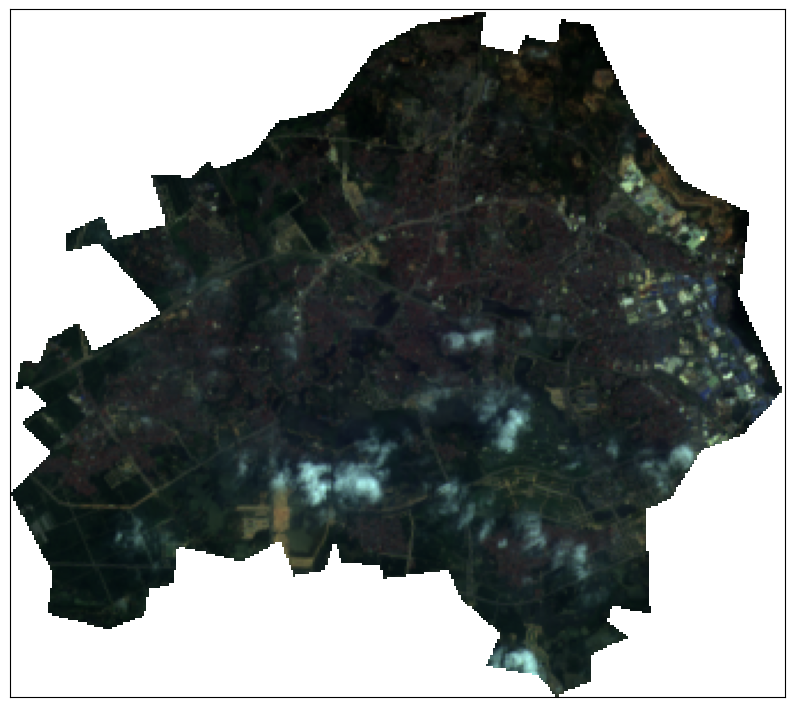

In [ ]:
from rasterio.plot import show
# Đọc dữ liệu ảnh landsat and hiển thị sử dụng show từ rasterio plot
file = r'G:\My Drive\python\geocourse\data\raster\landsat_rgbn.tif' # bạn cần thay đổi đường dẫn này thành đường dẫn đến file ảnh landsat đã được tạo ở bước trước
with rasterio.open(file) as src:
    fig, ax = plt.subplots(1,1, figsize=(10,10))
    show(src.read([3, 2, 1]), transform=src.transform, adjust='linear', ax=ax)
    ax.set_xticks([])
    ax.set_yticks([])

### 16.5.2. Trực quan hóa dùng matplotlib

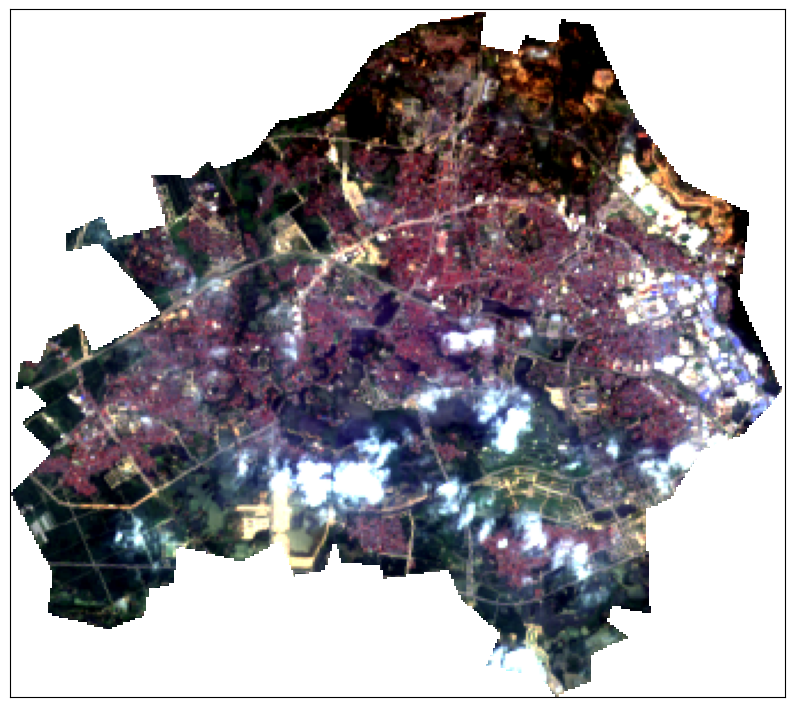

In [20]:
# Normalize each band (optional: clip outliers)
def normalize(band):
    p2, p98 = np.nanpercentile(band, (5, 95))  # clip 5–95% range
    return np.clip((band - p2) / (p98 - p2), 0, 1)
# Đọc dữ liệu ảnh landsat và hiển thị sử dụng matplotlib
with rasterio.open(file) as src:
    img = src.read([3, 2, 1])  # RGB
    rgb = np.stack([normalize(b) for b in img], axis=0)
    rgb = np.transpose(rgb, (1, 2, 0))  # reshape for imshow
    fig, ax = plt.subplots(figsize=(10, 10))
    extent = rasterio.plot.plotting_extent(src)
    ax.imshow(rgb, extent=extent)
    ax.set_xticks([]) # Bỏ trục tọa độ
    ax.set_yticks([]) # Bỏ trục tọa độ

## 16.6. Tính toán và Biến đổi Raster

Dữ liệu raster sau khi đọc chúng là các mảng numpy, chúng ta có thể áp dụng tất cả các phép tính và phân tích mà chúng ta thường làm với mảng numpy, chẳng hạn như tính toán chỉ số, lọc, phân loại. Sau khi thực hiện các phép tính này, chúng ta có thể lưu kết quả lại vào một file raster mới với các thông tin meta được cập nhật để phản ánh các thay đổi trong dữ liệu. 

### 16.6.1. Tính toán cơ bản

Do dữ liệu raster bản chất là một numpy array,chúng ta có thể thực hiện các phép tính toán học đơn giản như cộng, trừ, nhân, chia.

In [ ]:
# Đọc dữ liệu ảnh landsat
file = r'G:\My Drive\python\geocourse\data\raster\landsat_rgbn.tif'
with rasterio.open(file) as src:
    data = src.read()  # Dữ liệu ở định dạng numpy array. Ta có thể xử lý tương tự như các mảng numpy khác.
    out_meta = src.meta
    data = np.sqrt(data) * 5 + 10 -30 # Một số biến đổi đơn giản trên raster data

# Tính các chỉ số thống kê cơ bản
min_val = np.nanmin(data, axis=(1,2)) # Tính giá trị nhỏ nhất cho từng band
max_val = np.nanmax(data, axis=(1,2)) # Tính giá trị lớn nhất cho từng band
std_val = np.nanstd(data, axis=(1,2)) # Tính độ lệch chuẩn cho từng band
mean_val = np.nanmean(data, axis=(1,2)) # Tính giá trị trung bình cho từng band
print(f'Min values per band: {min_val}')
print(f'Max values per band: {max_val}')
print(f'Std values per band: {std_val}')
print(f'Mean values per band: {mean_val}')

### 16.6.2. Tính toán chỉ số thực vật

Trong ví dụ này, chúng ta sẽ tính toán các chỉ số thực vật dựa trên các kênh red và nir của ảnh Landsat. Sau khi tính toán các chỉ số như NDVI, SAVI và NDWI, chúng ta có thể lưu kết quả lại vào một file raster mới với các thông tin meta được cập nhật để phản ánh các thay đổi trong dữ liệu. Điều này cho phép chúng ta dễ dàng sử dụng các chỉ số này cho các phân tích tiếp theo hoặc hiển thị trên bản đồ.

In [ ]:
with rasterio.open(file) as src:
    data = src.read() 
    out_meta = src.meta

# Chúng ta có thể tính toán trên các mảng numpy như bình thường
# Ví dụ tính chỉ số NDVI
ndvi = (data[3] - data[2]) / (data[3] + data[2])
# Tính toán chỉ số SAVI 
savi = ((data[3] - data[2]) / (data[3] + data[2] + 0.5)) * (1.0 + 0.5)
# Tính toán chỉ số NDWI
ndwi = (data[1] - data[3]) / (data[1] + data[3])   

# Ta có thể lưu dữ liệu ra file  sử dụng out_meta (cập nhật lại số band) như các phần bên trên.
# Ví dụ stack các chỉ số thực vật vào với nhau
indices = np.stack([ndvi, savi, ndwi], axis=0)
outfile = r'G:\My Drive\python\geocourse\data\raster\landsat_indices.tif'
out_meta.update({
    'count': indices.shape[0] # Cập nhật số band mới
})
with rasterio.open(outfile, 'w', **out_meta) as dst:
    for i in range(1, indices.shape[0]+1):
        dst.write(indices[i-1], i)

### 16.6.3. Phân loại sức khỏe thực vật

Dữ liệu raster sau khi đọc chúng là mảng numpy, chúng ta có thể áp dụng tất cả các phép tính và phân tích mà chúng ta thường làm với mảng numpy, chẳng hạn như tính toán chỉ số, lọc, phân loại. 

In [ ]:
# Vị dụ phân loại ndvi thành các lớp sức khỏe thực vật (healthy [0.6, 1], moderate [0.2, 0.6), unhealthy [-0.2, 0.2), barren [-1, -0.2))
def ndvi_reclass(a):
    if a >= 0.6:
        return 4  # healthy
    elif 0.2 <= a < 0.6:
        return 3  # moderate
    elif -0.2 <= a < 0.2:
        return 2  # unhealthy
    else:
        return 1  # barren
# Vectorize the function to apply it on numpy array
ndvi_classes = np.vectorize(ndvi_reclass)(ndvi)
# Lưu kết quả phân loại ra file
outfile = r'G:\My Drive\python\geocourse\data\raster\ndvi_classes.tif'
out_meta.update({
    'count': 1  # Chỉ có 1 band cho kết quả phân loại
})
with rasterio.open(outfile, 'w', **out_meta) as dst:
    dst.write(ndvi_classes, 1)

## 16.7. Windowed Reading và Quản lý Bộ nhớ

Làm việc hiệu quả với large raster datasets đòi hỏi kỹ thuật tối ưu để tránh memory overflow.

- **Đọc dữ liệu theo kích thước mong muốn**

Rasterio cho phép người dùng đọc dữ liệu raster theo một window có kích thước mong muốn, giúp tiết kiệm bộ nhớ và tăng tốc độ xử lý khi chỉ cần làm việc với một phần nhỏ của raster. Sau khi đọc dữ liệu theo window, người dùng có thể thực hiện các phép tính và phân tích trên phần dữ liệu này, chẳng hạn như tính toán chỉ số, lọc, phân loại. Nếu cần thiết, kết quả có thể được lưu lại vào một file raster mới với các thông tin meta được cập nhật để phản ánh các thay đổi trong dữ liệu.

In [ ]:
file = r'G:\My Drive\python\geocourse\data\raster\landsat_rgbn.tif'
with rasterio.open(file) as src:
    # Đọc window nhỏ
    window_size = 100
    window = Window(50, 50, window_size, window_size)  # col_off, row_off, width, height
    window_data = src.read(window=window) # Đọc tất cả các band trong window, hoặc đọc một số band cụ thể bằng cách thêm parameter indexes=[1,2,3]
    # Tính meta cho window
    out_meta = src.meta.copy()
    # Cập nhật lại chiều cao, rộng và transform cho window
    out_meta.update({
        "height": window.height,
        "width": window.width,
        "transform": src.window_transform(window)
    })
    # Từ window có thể tính toán bounding box
    window_bounds = rasterio.windows.bounds(window, src.transform)
# Từ out_meta và window_data ta có thể lưu window ra file mới nếu cần thiết
outfile = r'G:\My Drive\python\geocourse\data\raster\landsat_window.tif'
with rasterio.open(outfile, 'w', **out_meta) as dst:
    dst.write(window_data)

Window bounds: (105.56264600439638, 21.30570291957634, 105.58959546291997, 21.332652378099926)


- **Đọc dữ liệu theo 256x256 window**

Việc chia nhỏ raster thành các tile nhỏ hơn có thể hữu ích cho việc xử lý dữ liệu lớn hoặc để phục vụ cho các phân tích khác nhau như huấn luyện các mô hình học sâu. Trong ví dụ này, chúng ta tạo ra các tile có kích thước 256x256 pixel từ một raster lớn hơn, và cập nhật meta data cho mỗi tile để đảm bảo rằng chúng vẫn giữ được thông tin về vị trí và hệ tọa độ. 

In [ ]:
tile_size = 256
with rasterio.open(file) as src:
    # Đọc dữ liệu raster
    data = src.read()
    out_meta = src.meta
    for row_off in range(0, src.height, tile_size):
        for col_off in range(0, src.width, tile_size):
            width = min(tile_size, src.width - col_off)
            height = min(tile_size, src.height - row_off)
            window = Window(col_off, row_off, width, height)
            subset = src.read(window=window)
            # Cập nhật meta cho tile
            tile_meta = out_meta.copy()
            tile_meta.update({
                "height": height,
                "width": width,
                "transform": src.window_transform(window)
            })
            # Lưu tile ra file mới
            filename = f"tile_{row_off}_{col_off}.tif"
            # with rasterio.open(filename, "w", **tile_meta) as dest:
            #     dest.write(subset)
            print(filename)

tile_0_0.tif
tile_0_256.tif
tile_256_0.tif
tile_256_256.tif


- **Sử dụng block-based để xử lý dữ liệu lớn**

Trong ví dụ này, chúng ta sử dụng `block-based` để đọc dữ liệu raster theo từng block nhỏ, giúp tiết kiệm bộ nhớ và tăng tốc độ xử lý khi làm việc với các raster lớn. Việc duyệt qua từng block cho phép chúng ta thực hiện các phép tính và phân tích trên phần dữ liệu nhỏ hơn, tránh việc phải tải toàn bộ raster vào bộ nhớ cùng một lúc.

In [ ]:
# Sử dụng block-based reading để xử lý raster lớn. Ví dụ này minh họa và raster không quá lớn.
file = r'G:\My Drive\python\geocourse\data\raster\landsat_rgbn.tif'
with rasterio.open(file) as src:
    # Lấy kích thước block
    block_shapes = src.block_shapes
    print(f'Block shapes: {len(block_shapes)}')
    # Duyệt qua từng block
    for ji, window in src.block_windows(1):  # Chỉ đọc band 1
        block_data = src.read(1, window=window)  # Đọc dữ liệu block
        # Thực hiện các phép tính trên block_data ở đây
        # Ví dụ tính giá trị trung bình của block
        block_mean = np.nanmean(block_data)
        print(f'Block {ji} mean value: {block_mean:.2f}')

Block shapes: 4
Block (0, 0) mean value: 0.17
Block (0, 1) mean value: 0.18
Block (1, 0) mean value: 0.17
Block (1, 1) mean value: 0.17


## 16.8. Lưu dữ liệu và chuyển đổi hệ tọa độ
Phần cuối này bao gồm các kỹ thuật nâng cao để xuất, biến đổi và tối ưu hóa raster data.

### 16.8.1. Lưu dữ liệu với `compression`

Dữ liệu raster có thể rất lớn, việc sử dụng các tùy chọn nén khi lưu file có thể giúp giảm đáng kể dung lượng file mà không làm mất nhiều thông tin. Các phương pháp nén phổ biến như LZW, Deflate hoặc JPEG có thể được áp dụng tùy thuộc vào loại dữ liệu và yêu cầu về chất lượng. Khi đọc dữ liệu đã được nén, rasterio sẽ tự động giải nén để bạn có thể làm việc với dữ liệu như bình thường.

In [ ]:
# Lưu dữ liệu ra file với các compression options để giảm dung lượng file
# Một vài options phổ biến: 'lzw', 'deflate', 'jpeg'
outfile = r'G:\My Drive\python\geocourse\data\raster\landsat_copressed.tif'
# Ví dụ đọc và lưu lại với nén LZW cho 1 band 
file = r'G:\My Drive\python\geocourse\data\raster\landsat_rgbn.tif'
with rasterio.open(file) as src:
    data = src.read(1)  # Đọc band 1
    out_meta = src.meta.copy()
    out_meta.update({
        'compress': 'lzw'  # Thêm option nén LZW
    })
    # with rasterio.open(outfile, 'w', **out_meta) as dest:
    #     dest.write(data, 1)

### 16.8.2. Reproject dữ liệu từ một hệ tọa độ sang hệ tọa độ khác

Bạn có thể sử dụng hàm `reproject` của rasterio để chuyển đổi hệ tọa độ của raster từ WGS84 sang UTM Zone 48N. Hàm này sẽ tự động tính toán transform mới, kích thước mới và thực hiện việc reprojection cho từng band của raster. Việc này rất hữu ích khi bạn cần làm việc với dữ liệu raster trong một hệ tọa độ khác để phù hợp với các phân tích địa lý hoặc hiển thị trên bản đồ.

In [ ]:
# Reproject raster từ WGS84 sang UTM Zone 48N
src_crs = CRS.from_epsg(4326)  # WGS84
dst_crs = CRS.from_epsg(32648)  # UTM Zone 48N
file = r'G:\My Drive\python\geocourse\data\raster\landsat_rgbn.tif'
outfile = r'G:\My Drive\python\geocourse\data\raster\landsat_rgbn_utm48n.tif'
with rasterio.open(file) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    out_meta = src.meta.copy()
    out_meta.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height,
        "nodata": src.nodata if src.nodata is not None else 0  # Set nodata if not present
    })
    with rasterio.open(outfile, 'w', **out_meta) as dest:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dest, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest)         

### 16.8.3. Clip raster theo vector

Clip dữ liệu raster là việc sử dụng một đa giác (polygon) để cắt bỏ phần dữ liệu raster nằm ngoài đa giác đó, giữ lại chỉ phần dữ liệu bên trong. Điều này rất hữu ích khi bạn chỉ quan tâm đến một khu vực nghiên cứu cụ thể và muốn loại bỏ các phần dữ liệu không liên quan, giúp tiết kiệm bộ nhớ và tăng tốc độ xử lý cho các phân tích tiếp theo.

In [ ]:
poly = gpd.read_file(r"G:\My Drive\python\geocourse\data\vector\subset_polygon.geojson")
# Clip raster sử dụng poly 
file = r'G:\My Drive\python\geocourse\data\raster\landsat_rgbn.tif'
outfile = r'G:\My Drive\python\geocourse\data\raster\landsat_rgbn_clipped.tif'
with rasterio.open(file) as src:
    out_img, out_transform = mask(src, poly.geometry.to_list(), crop=True)
    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_img.shape[1],
        "width": out_img.shape[2],
        "transform": out_transform
    })
    with rasterio.open(outfile, "w", **out_meta) as dest:
        dest.write(out_img)

## Tóm tắt

Bạn đã hoàn thành Bài 6 và học được Rasterio - thư viện chuyên nghiệp cho raster data processing trong Python ecosystem.

### Các khái niệm chính đã nắm vững:
- ✅ **Raster I/O**: Đọc và ghi raster datasets với metadata và profile management
- ✅ **Coordinate systems**: Transform matrices, CRS operations và reprojection workflows
- ✅ **Visualization**: Advanced plotting với matplotlib integration và custom colormaps
- ✅ **Band operations**: Mathematical calculations, spectral indices (NDVI, NDWI, SAVI)
- ✅ **Memory optimization**: Windowed reading và block-based processing cho big data
- ✅ **Advanced operations**: Clipping, masking, warping và geometric transformations
- ✅ **Format optimization**: Compression strategies, tiling và cloud-optimized workflows
### Kỹ năng bạn có thể áp dụng:
- Xử lý và phân tích satellite imagery và aerial photography một cách chuyên nghiệp
- Thực hiện remote sensing workflows cho environmental monitoring và agriculture
- Optimize raster processing performance cho production-scale geospatial applications
- Tích hợp Rasterio với NumPy và scientific Python stack cho advanced analysis
- Chuẩn bị foundation expertise cho computer vision và machine learning trên geospatial data